# Чекпоинт 6. Применение DL-моделей

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# !ln -s /content/drive/MyDrive/HSE/YearProject/* .

In [ ]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from collections import Counter
from typing import Iterable

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering, HDBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import PCA

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from data_utils import (
    clean_text, preprocess_data, calc_metrics, extract_ngrams, find_templates,
    remove_templates, clean_templates_in_df, load_and_prepare_data
)
from cluster_utils import (
    get_X_2d, plot_clusters_2d, plot_cluster_centroids_with_texts, plot_clusters_3d,
    plot_cluster_channel_heatmap, get_X_3d, plot_clusters_3d_matplotlib, draw_cluster_sizes,
    get_top_texts_per_cluster, get_cluster_density
)

import nltk
from nltk.corpus import stopwords
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from tqdm import tqdm

RANDOM_STATE = 42

In [3]:
try:
    nltk.download('punkt')
    nltk.download('stopwords')
except:
    pass

russian_stopwords = set(stopwords.words('russian'))
extra_stopwords = set(["это", "подписаться"])
stopwords_list = list(russian_stopwords.union(extra_stopwords))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 0. Загрузка данных

In [4]:
df = load_and_prepare_data('raw_posts_labeled.csv')
df.head()

[*] Строк после удаления пустых текстов: 11200
[*] Очищаем тексты...
[*] Убрали слишком короткие тексты: 11200 → 11159


,id,date,channel,topic,text,text_clean,text_clean2
0,144954,2026-03-11T16:20:30+00:00,@rbc_news,economy,**Ответственность за атаку на начальную школу ...,ответственность за атаку на начальную школу в ...,ответственность за атаку на начальную школу в ...
1,144953,2026-03-11T16:20:24+00:00,@rbc_news,economy,Банковский финансовый мониторинг становится бо...,банковский финансовый мониторинг становится бо...,банковский финансовый мониторинг становится бо...
2,144952,2026-03-11T16:10:42+00:00,@rbc_news,economy,🎙 Прямо сейчас в эфире Радио РБК — **связь все...,прямо сейчас в эфире радио рбк связь все еще р...,прямо сейчас в эфире радио рбк связь все еще р...
3,144951,2026-03-11T15:59:30+00:00,@rbc_news,economy,🔵[Олимпийский комитет России станет владельцем...,олимпийский комитет россии станет владельцем г...,олимпийский комитет россии станет владельцем г...
4,144950,2026-03-11T15:44:01+00:00,@rbc_news,economy,"Бывший помощник главы государства, экс-замести...",бывший помощник главы государства экс заместит...,бывший помощник главы государства экс заместит...


In [5]:
X_text = df['text_clean2']

## 1. Заменим векторизацию

In [ ]:
!pip install gensim

In [7]:
import gensim
# from gensim.models.word2vec import Word2Vec
# from gensim.models.fasttext import FastText
# import gensim.downloader as download_api

In [8]:
%%time

# Модели взяты с https://rusvectores.org/ru/models/
# Здесь используется модель geowac_lemmas_none_fasttextskipgram_300_5_2020
model_path = 'models/213/model.model'
model = gensim.models.KeyedVectors.load(model_path)

CPU times: user 5.6 s, sys: 2.07 s, total: 7.67 s
Wall time: 53.2 s


In [9]:
X_data = df["text_clean2"]
y_data = df["topic"]
X_extra = df[['date', 'channel', 'topic']]

X_train_text, X_test_text, \
y_train_topic, y_test_topic, \
X_extra_train, X_extra_test \
    = train_test_split(X_data, y_data, X_extra, test_size=0.3, random_state=RANDOM_STATE)

# X_data = df["text_clean2"]
# y_data = df["topic"]

In [10]:
def text_to_vector(text, model):
    words = text.split()
    vectors = []

    for word in words:
        if word in model:
            vectors.append(model[word])

    if len(vectors) == 0:
        return np.zeros(300)

    return np.mean(vectors, axis=0)

In [11]:
X_train = np.array([text_to_vector(text, model) for text in tqdm(X_train_text)])
X_test = np.array([text_to_vector(text, model) for text in tqdm(X_test_text)])

100%|██████████| 3315/3315 [00:03<00:00, 852.75it/s]


В этом разделе воспользовались готовой моделью FastText для векторизации текста. Далее вместо TF-IDF будем пользоваться этой моделью.

## 2. Классификация на новых эмбеддингах

In [12]:
le = LabelEncoder()
y_train = le.fit_transform(y_train_topic)
y_test = le.transform(y_test_topic)

Ранее для классификации использовали MultinomialNB, но поскольку в новых эмбеддингах появились отрицательные значения, то заменим модель на GaussianNB

In [ ]:
# base_model = MultinomialNB(alpha=0.1)
# base_model.fit(X_train, y_train)

In [13]:
from sklearn.naive_bayes import GaussianNB

base_model = GaussianNB()
base_model.fit(X_train, y_train)

GaussianNB()

In [14]:
calc_metrics(y_test, base_model.predict(X_test))

{'f1_macro': 0.6420088924036191,
 'accuracy': 0.6180995475113122,
 'precision_macro': 0.6569614822596792,
 'recall_macro': 0.6763585003071465}

Метрики для новой модели получились хуже. Вот метрики для модели MultinomialNB с TF-IDF

|metric|value|
|------|-----|
|f1_macro|0.8308|
|accuracy|0.8144|
|precision_macro|0.8377|
|recall_macro|0.8273|


Попробуем логистическую регрессию

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

In [16]:
calc_metrics(y_test, lr.predict(X_test))

{'f1_macro': 0.8124243685131335,
 'accuracy': 0.8018099547511313,
 'precision_macro': 0.819545661409197,
 'recall_macro': 0.8082874005732261}

При векторизации текста с помощью FastText логистическая регрессия работает лучше. Метрики достаточно близки к модели с использованием TF-IDF

## 3. Кластеризация

In [17]:
def not_grid_search(model, data, n_clusters: Iterable | None = None,
                    eps_list: Iterable | None = None, min_samples_list: Iterable | None = None,
                    min_cluster_size_list: Iterable | None = None, metric: str = 'cosine'):

    scorers = {
        'silhouette_score': silhouette_score,
        'davies_bouldin_score': davies_bouldin_score
    }

    results = []

    def add_scores(result, clusters_topic):
        for scorer_name, scorer in scorers.items():
            result[scorer_name] = scorer(data, clusters_topic)

    def print_result(result: dict):
        items = [f'{key}={value:.4f}' for key, value in result.items()]
        print(' '.join(items))

    def create_and_print_result(result: dict):
        add_scores(result, clusters_topic)
        print_result(result)
        results.append(result)

    if n_clusters is not None:
        for n in n_clusters:
            try:
                estimator = model(n_clusters=n, random_state=RANDOM_STATE)
            except:
                estimator = model(n_clusters=n)
            clusters_topic = estimator.fit_predict(data)
            create_and_print_result({
                'n_clusters': n
            })

    elif eps_list is not None and min_samples_list is not None:
        for eps in eps_list:
            for min_samples in min_samples_list:
                estimator = model(eps=eps, min_samples=min_samples, metric=metric)
                clusters_topic = estimator.fit_predict(data)
                n_clusters_dbscan = len(set(clusters_topic)) - (1 if -1 in clusters_topic else 0)
                if n_clusters_dbscan > 1:
                    create_and_print_result({
                        'eps': eps,
                        'min_samples': min_samples,
                        'n_clusters': n_clusters_dbscan
                    })

    elif min_cluster_size_list is not None:
        for min_cluster_size in min_cluster_size_list:
            if min_samples_list is None:
                min_samples_list = [None]
            for min_samples in min_samples_list:
                estimator = model(min_cluster_size=min_cluster_size, min_samples=min_samples, metric=metric)
                clusters_topic = estimator.fit_predict(data)
                n_clusters_hdbscan = len(set(clusters_topic)) - (1 if -1 in clusters_topic else 0)
                if n_clusters_hdbscan > 1:
                    result = {
                        'min_cluster_size': min_cluster_size,
                        'n_clusters': n_clusters_hdbscan
                    }
                    if min_samples is not None:
                        result['min_samples'] = min_samples
                    create_and_print_result(result)

    return results

Выберем тему

In [18]:
topic = y_train_topic.unique()[4]
topic

'sport'

In [19]:
df_topic = df[df['topic'] == topic]

X_topic_data = df_topic["text_clean2"]
X_topic_extra = df_topic[['date', 'channel', 'topic']]

In [20]:
X_topic_vectorized = np.array([text_to_vector(text, model) for text in tqdm(X_topic_data)])

100%|██████████| 938/938 [00:00<00:00, 1891.42it/s]


Сразу добавим дополнительные признаки. Не могу объяснить, почему, но мне кажется, что некоторые признаки работают плохо или неправильно. Например, одинаковое значение часа в сутках, возможно, будет путать модель. Поэтому в этой версии я хотел бы немного изменить эти признаки.

In [21]:
def extract_temporal_features(date_feature):
    date_feature = pd.to_datetime(date_feature)

    features = {
        # 'hour': date_feature.dt.hour,
        # 'day_of_week': date_feature.dt.dayofweek,
        'timestamp': date_feature.dt.strftime('%s').astype(int)
    }

    return features

In [22]:
X_datetime = extract_temporal_features(X_topic_extra['date'])
X_datetime = pd.DataFrame(X_datetime)

dt_scaler = MinMaxScaler()
X_datetime = pd.DataFrame(dt_scaler.fit_transform(X_datetime), columns=X_datetime.columns)

X_datetime

,timestamp
0,1.000000
1,0.999603
2,0.998314
3,0.996842
4,0.996322
...,...
933,0.004732
934,0.003155
935,0.001577
936,0.001194


In [23]:
def extract_structural_features(text_feature):
    features = {
        'len': text_feature.apply(len),
        'word_count': text_feature.apply(lambda x: len(x.split())),
        # 'question_marks': text_feature.apply(lambda x: x.count('?')),
        # 'exclamation_marks': text_feature.apply(lambda x: x.count('1')),
        # 'digit_ratio': text_feature.apply(
            # lambda text: sum(1 for c in text if c.isdigit()) / max(1, len(text))
        # )
    }
    return features

In [24]:
X_structure = extract_structural_features(X_topic_data)
X_structure = pd.DataFrame(X_structure)

st_scaler = MinMaxScaler()
X_structure = pd.DataFrame(st_scaler.fit_transform(X_structure), columns=X_structure.columns)

X_structure

,len,word_count
0,0.028852,0.027451
1,0.018768,0.027451
2,0.037535,0.041176
3,0.107843,0.125490
4,0.063305,0.072549
...,...,...
933,0.067227,0.064706
934,0.090476,0.111765
935,0.071429,0.072549
936,0.075910,0.068627


In [25]:
X_for_clustering = np.hstack([
    X_topic_vectorized,
    X_datetime,
    X_structure
])

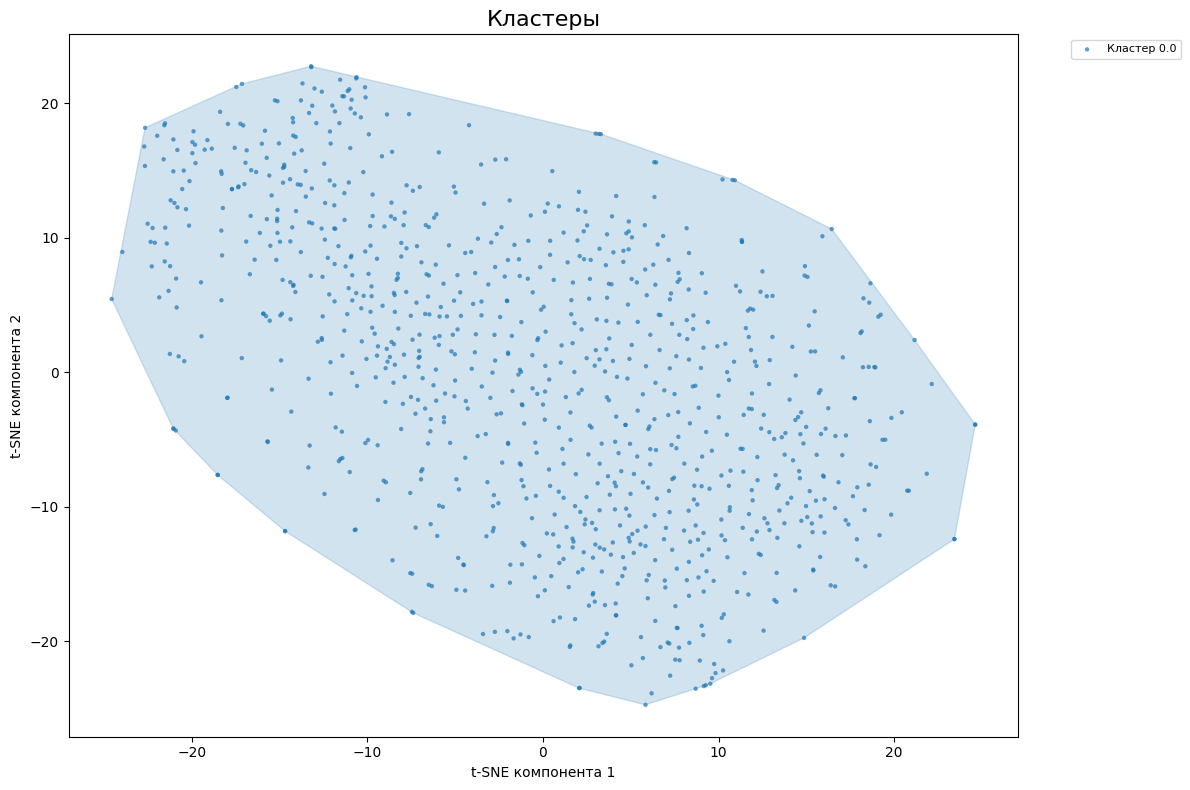

In [ ]:
X_for_2d = get_X_2d(X_for_clustering)
zero_labels = np.zeros((X_for_clustering.shape[0],))
plot_clusters_2d(X_for_clustering, zero_labels, X_for_2d)

#### KMeans

In [28]:
best_kmeans = not_grid_search(KMeans, X_for_clustering, np.arange(2, 100, 3))

n_clusters=2.0000 silhouette_score=0.0963 davies_bouldin_score=2.9228
n_clusters=5.0000 silhouette_score=0.0543 davies_bouldin_score=3.5694
n_clusters=8.0000 silhouette_score=0.0282 davies_bouldin_score=3.9157
n_clusters=11.0000 silhouette_score=0.0246 davies_bouldin_score=3.7425
n_clusters=14.0000 silhouette_score=0.0158 davies_bouldin_score=3.5778
n_clusters=17.0000 silhouette_score=0.0162 davies_bouldin_score=3.3231
n_clusters=20.0000 silhouette_score=0.0150 davies_bouldin_score=3.3827
n_clusters=23.0000 silhouette_score=0.0119 davies_bouldin_score=3.3888
n_clusters=26.0000 silhouette_score=0.0094 davies_bouldin_score=3.2450
n_clusters=29.0000 silhouette_score=0.0098 davies_bouldin_score=3.2670
n_clusters=32.0000 silhouette_score=0.0087 davies_bouldin_score=3.0581
n_clusters=35.0000 silhouette_score=0.0105 davies_bouldin_score=2.9594
n_clusters=38.0000 silhouette_score=0.0124 davies_bouldin_score=2.8567
n_clusters=41.0000 silhouette_score=0.0076 davies_bouldin_score=2.8732
n_cluster

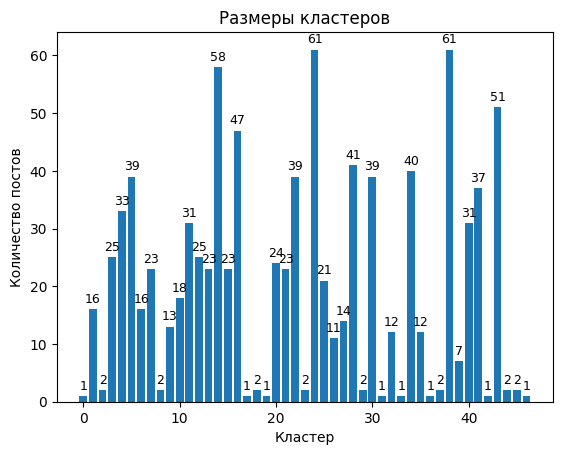

In [29]:
kmeans_topic = KMeans(n_clusters=47, random_state=RANDOM_STATE)
clusters_kmeans_topic = kmeans_topic.fit_predict(X_for_clustering)

draw_cluster_sizes(clusters_kmeans_topic)

In [ ]:
# plot_clusters_2d(X_for_clustering, clusters_kmeans_topic, X_for_2d, add_legend=False)

In [ ]:
# top_clusters_texts_ = get_top_texts_per_cluster(X_topic_data, clusters_kmeans_topic, X_for_clustering)
# top_clusters_density = get_cluster_density(X_for_clustering, clusters_kmeans_topic)

# print_top_of_clusters(top_clusters_texts_, top_clusters_density)

#### Hierarchy

In [34]:
best_hierarchical = not_grid_search(AgglomerativeClustering, X_for_clustering, np.arange(2, 300, 10))

n_clusters=2.0000 silhouette_score=0.0851 davies_bouldin_score=3.1796
n_clusters=12.0000 silhouette_score=0.0156 davies_bouldin_score=3.6761
n_clusters=22.0000 silhouette_score=0.0060 davies_bouldin_score=3.4427
n_clusters=32.0000 silhouette_score=0.0011 davies_bouldin_score=3.1538
n_clusters=42.0000 silhouette_score=-0.0030 davies_bouldin_score=2.8641
n_clusters=52.0000 silhouette_score=-0.0041 davies_bouldin_score=2.6665
n_clusters=62.0000 silhouette_score=0.0016 davies_bouldin_score=2.6608
n_clusters=72.0000 silhouette_score=0.0055 davies_bouldin_score=2.5259
n_clusters=82.0000 silhouette_score=0.0073 davies_bouldin_score=2.4006
n_clusters=92.0000 silhouette_score=0.0056 davies_bouldin_score=2.2978
n_clusters=102.0000 silhouette_score=0.0057 davies_bouldin_score=2.1870
n_clusters=112.0000 silhouette_score=0.0042 davies_bouldin_score=2.1202
n_clusters=122.0000 silhouette_score=0.0055 davies_bouldin_score=2.0694
n_clusters=132.0000 silhouette_score=0.0060 davies_bouldin_score=2.0115
n

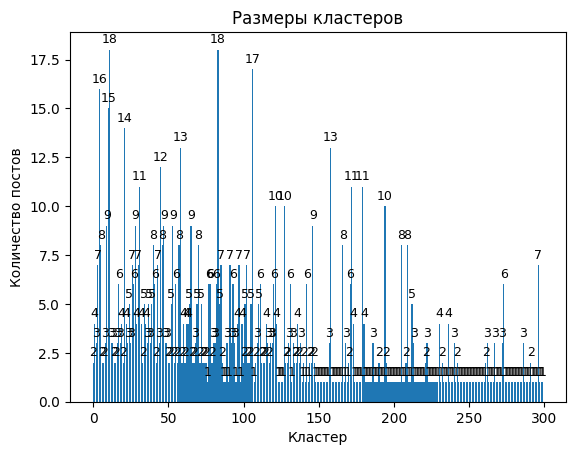

CPU times: user 819 ms, sys: 12.1 ms, total: 831 ms
Wall time: 834 ms


In [33]:
%%time

hierarchical_topic = AgglomerativeClustering(n_clusters=300)
clusters_hier_topic = hierarchical_topic.fit_predict(X_for_clustering)

draw_cluster_sizes(clusters_hier_topic)

In [ ]:
# plot_clusters_2d(X_for_clustering, clusters_hier_topic, X_for_2d, add_legend=False)

In [ ]:
# print_top_of_clusters(
#     get_top_texts_per_cluster(X_topic_data, clusters_hier_topic, X_for_clustering),
#     get_cluster_density(X_for_clustering, clusters_hier_topic)
# )

####  DBSCAN

In [35]:
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_for_clustering)

In [36]:
from sklearn.preprocessing import normalize
X_norm = normalize(X_for_clustering)

In [39]:
best_dbscan = not_grid_search(
    DBSCAN, X_scaled,
    eps_list=np.arange(0.1, 0.3, 0.05), min_samples_list=np.arange(2, 5, 1)
)

eps=0.1000 min_samples=2.0000 n_clusters=7.0000 silhouette_score=0.0035 davies_bouldin_score=3.5544
eps=0.1000 min_samples=3.0000 n_clusters=2.0000 silhouette_score=0.0117 davies_bouldin_score=7.4042
eps=0.1500 min_samples=2.0000 n_clusters=2.0000 silhouette_score=0.2280 davies_bouldin_score=5.4390
eps=0.2000 min_samples=2.0000 n_clusters=2.0000 silhouette_score=0.3514 davies_bouldin_score=2.2620


In [40]:
best_dbscan = not_grid_search(
    DBSCAN, X_norm,
    eps_list=np.arange(0.1, 0.6, 0.05), min_samples_list=np.arange(2, 10, 1),
    metric='euclidean'
)

eps=0.3000 min_samples=2.0000 n_clusters=9.0000 silhouette_score=-0.1796 davies_bouldin_score=1.5492
eps=0.3500 min_samples=2.0000 n_clusters=22.0000 silhouette_score=-0.1859 davies_bouldin_score=1.8991
eps=0.3500 min_samples=3.0000 n_clusters=4.0000 silhouette_score=-0.1426 davies_bouldin_score=2.9638
eps=0.3500 min_samples=4.0000 n_clusters=2.0000 silhouette_score=-0.1029 davies_bouldin_score=3.4676
eps=0.3500 min_samples=6.0000 n_clusters=2.0000 silhouette_score=-0.1072 davies_bouldin_score=2.8906
eps=0.3500 min_samples=7.0000 n_clusters=2.0000 silhouette_score=-0.1087 davies_bouldin_score=2.8084
eps=0.3500 min_samples=8.0000 n_clusters=2.0000 silhouette_score=-0.1095 davies_bouldin_score=2.6918
eps=0.3500 min_samples=9.0000 n_clusters=3.0000 silhouette_score=-0.1250 davies_bouldin_score=2.5190
eps=0.4000 min_samples=2.0000 n_clusters=22.0000 silhouette_score=-0.1246 davies_bouldin_score=2.1199
eps=0.4000 min_samples=3.0000 n_clusters=4.0000 silhouette_score=-0.0740 davies_bouldin_s

DBSCAN нашел 9 кластеров + шум


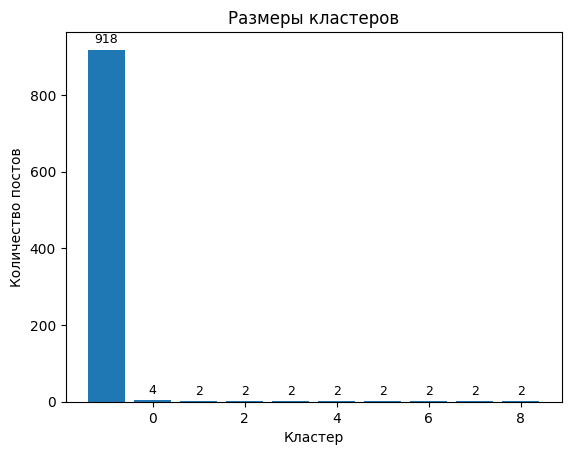

In [44]:
# metric = 'cosine'
# X_dbscan = X_scaled
# eps = 0.2
# min_samples = 2

metric = 'euclidean'
X_dbscan = X_norm
eps = 0.3
min_samples = 2

dbscan_topic = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
clusters_dbscan_topic = dbscan_topic.fit_predict(X_dbscan)
n_clusters_dbscan = len(set(clusters_dbscan_topic)) - (1 if -1 in clusters_dbscan_topic else 0)

print(f"DBSCAN нашел {n_clusters_dbscan} кластеров{' + шум' if -1 in clusters_dbscan_topic else ' без шума'}")

draw_cluster_sizes(clusters_dbscan_topic)

In [ ]:
# plot_clusters_2d(X_for_clustering, clusters_dbscan_topic, X_for_2d)

In [ ]:
# print_top_of_clusters(
#     get_top_texts_per_cluster(X_topic_data, clusters_dbscan_topic, X_for_clustering),
#     get_cluster_density(X_for_clustering, clusters_dbscan_topic)
# )

#### HDBSCAN

In [45]:
best_hdbscan = not_grid_search(HDBSCAN, X_scaled, min_cluster_size_list=np.arange(2, 15, 1))

min_cluster_size=2.0000 n_clusters=2.0000 silhouette_score=0.3251 davies_bouldin_score=0.6073
min_cluster_size=3.0000 n_clusters=2.0000 silhouette_score=0.0122 davies_bouldin_score=7.5125
min_cluster_size=4.0000 n_clusters=4.0000 silhouette_score=-0.1305 davies_bouldin_score=3.5044
min_cluster_size=5.0000 n_clusters=2.0000 silhouette_score=-0.1097 davies_bouldin_score=4.0076


In [46]:
%%time
best_hdbscan = not_grid_search(HDBSCAN, X_norm, min_cluster_size_list=np.arange(2, 15, 2), metric='euclidean')

min_cluster_size=2.0000 n_clusters=2.0000 silhouette_score=0.2157 davies_bouldin_score=1.4796
min_cluster_size=4.0000 n_clusters=3.0000 silhouette_score=-0.0893 davies_bouldin_score=3.6562
CPU times: user 6.14 s, sys: 13.2 ms, total: 6.16 s
Wall time: 9.95 s


HDBSCAN нашел 2 кластеров + шум


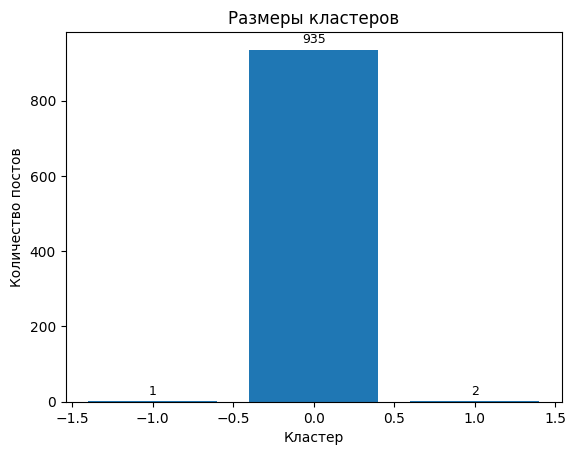

In [47]:
metric = 'cosine'
X_hdbscan = X_scaled
min_cluster_size = 2

# metric = 'euclidean'
# X_hdbscan = X_norm
# min_cluster_size = 2

hdbscan_topic = HDBSCAN(min_cluster_size=min_cluster_size, metric=metric)
clusters_hdbscan_topic = hdbscan_topic.fit_predict(X_hdbscan)
n_clusters_hdbscan = len(set(clusters_hdbscan_topic)) - (1 if -1 in clusters_hdbscan_topic else 0)

print(f"HDBSCAN нашел {n_clusters_hdbscan} кластеров{' + шум' if -1 in clusters_hdbscan_topic else ' без шума'}")

draw_cluster_sizes(clusters_hdbscan_topic)

In [ ]:
# plot_clusters_2d(X_for_clustering, clusters_hdbscan_topic, X_for_2d, add_legend=False)

#### Спектральная кластеризация

In [51]:
n_samples = min(5000, X_for_clustering.shape[0])
X_sample = X_for_clustering[:n_samples]

pca = PCA(n_components=150, random_state=RANDOM_STATE)
X_reduced = pca.fit_transform(X_sample)

print(f"После PCA: {X_reduced.shape}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

# X_reduced = X_for_clustering

После PCA: (938, 150)
Объясненная дисперсия: 91.27%


In [54]:
%%time
best_spectral = not_grid_search(SpectralClustering, X_reduced, np.arange(2, 120, 8))

n_clusters=2.0000 silhouette_score=0.1057 davies_bouldin_score=2.7669
n_clusters=10.0000 silhouette_score=0.0226 davies_bouldin_score=3.1040
n_clusters=18.0000 silhouette_score=0.0149 davies_bouldin_score=3.3023
n_clusters=26.0000 silhouette_score=0.0057 davies_bouldin_score=3.1649
n_clusters=34.0000 silhouette_score=0.0075 davies_bouldin_score=3.0421
n_clusters=42.0000 silhouette_score=0.0065 davies_bouldin_score=2.7608
n_clusters=50.0000 silhouette_score=0.0027 davies_bouldin_score=2.3916
n_clusters=58.0000 silhouette_score=-0.0053 davies_bouldin_score=2.4517
n_clusters=66.0000 silhouette_score=-0.0092 davies_bouldin_score=2.3831
n_clusters=74.0000 silhouette_score=0.0077 davies_bouldin_score=2.2348
n_clusters=82.0000 silhouette_score=0.0019 davies_bouldin_score=2.1001
n_clusters=90.0000 silhouette_score=-0.0103 davies_bouldin_score=1.9015
n_clusters=98.0000 silhouette_score=-0.0069 davies_bouldin_score=1.8390
n_clusters=106.0000 silhouette_score=-0.0198 davies_bouldin_score=1.9150
n

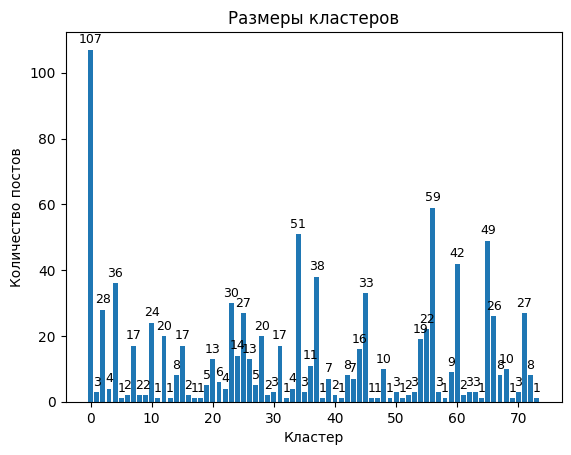

In [55]:
spectral_topic = SpectralClustering(n_clusters=74, random_state=RANDOM_STATE)
clusters_spectral_topic = spectral_topic.fit_predict(X_reduced)

draw_cluster_sizes(clusters_spectral_topic)

In [ ]:
# plot_clusters_2d(X_reduced, clusters_spectral_topic, add_legend=False)

## 4. Суммаризация

Попытаемся на основе текстов в одном кластере сформировать один текст, который опишет кластер

In [56]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

In [ ]:
summ_model_name = "cointegrated/rut5-base-multitask"
tokenizer = T5Tokenizer.from_pretrained(summ_model_name)
summ_model = T5ForConditionalGeneration.from_pretrained(summ_model_name)

In [57]:
def width_print(text, width=80, title=None):
    curr = 0
    if title:
        print(title)
    while curr < len(text):
        print('....', text[curr:curr+width])
        curr += width

In [65]:
def get_texts_for_summarize(cluster_topic):
    top_clusters_texts_ = get_top_texts_per_cluster(X_topic_data, cluster_topic, X_for_clustering, n_top=10)
    top_clusters_density = get_cluster_density(X_for_clustering, cluster_topic)

    unique, counts = np.unique(cluster_topic, return_counts=True)
    cluster_counts = [(count_item, unique_item) for unique_item, count_item in zip(unique, counts)]
    cluster_counts.sort(reverse=True)

    texts = []
    for count, cluster in cluster_counts:
        density = top_clusters_density[cluster]
        if count < 3 or density == 0:
            continue
        texts.append({
            'cluster': cluster,
            'texts': [text for text, distance in top_clusters_texts_[cluster]],
            'density': density,
            'size': count
        })

    return texts

In [66]:
def generate_summary(texts, max_length=150, min_length=40):
    combined = " [SEP] ".join(texts)  # спецтокен между постами

    # Формат для T5: нужно указать задачу
    input_text = f"summarize: {combined}"

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=600,
        truncation=True
    )

    with torch.no_grad():
        summary_ids = summ_model.generate(
            inputs["input_ids"],
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            temperature=0.7,
            repetition_penalty=2.0,
            early_stopping=True
        )

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary


In [67]:
limit = 10
for cluster_texts in get_texts_for_summarize(clusters_kmeans_topic):
    limit -= 1
    if limit < 0:
        break
    print(cluster_texts['cluster'], f'({cluster_texts["density"]:.4f})')
    for curr_text in cluster_texts['texts'][:3]:
        width_print(curr_text[:200], 100, 'text')
    result = generate_summary(cluster_texts['texts'], max_length=300)
    width_print(result, 100, 'SUMMARIZE')
    print()

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


38 (0.0691)
text
.... янника синнера поймали фанаты на выходе из магазина в руках у итальянца была упаковка туалетной бума
.... ги но это не помешало ему невозмутимо дать автограф на кроссовке болельщика после этого теннисист ка
text
.... организаторы мастерса в индиан уэллсе подарили соболенко огромное кольцо с розовыми теннисными мячам
.... и арина обыграла японку сакацуме прямо в своем помолвочном украшении за млн долларов я чувствовала с
text
.... игроки атлетико выйдут на матч с хетафе в сопровождении людей в образе персонажей острых козырьков а
....  на стадионе появятся бар и барбершоп стилизованные под бирмингем х годов the athletic мадридский кл
SUMMARIZE
.... теннисистка мирра рыбакина изящно не дала обнять себя на церемонии выставочного чемпионата в Индиан 
.... уэллсе там выиграла млн долларов

24 (0.0750)
text
.... реал в третий раз за месяц сыграет с бенфикой в лиге чемпионов пока у команд по одной победе но порт
.... угальцы забили на мяч больше выйдут ли винисиус и мбап

In [68]:
limit = 10
for cluster_texts in get_texts_for_summarize(clusters_hier_topic):
    limit -= 1
    if limit < 0:
        break
    print(cluster_texts['cluster'], f'({cluster_texts["density"]:.4f})')
    for curr_text in cluster_texts['texts'][:3]:
        width_print(curr_text[:200], 100, 'text')
    result = generate_summary(cluster_texts['texts'], max_length=300)
    width_print(result, 100, 'SUMMARIZE')
    print()

83 (0.0493)
text
.... сразу после победы сити над ньюкаслом гвардиола улетел в италию на матч брешии в серии с в начале ну
.... левых пеп сам играл в брешии вместе с роберто баджо а сейчас старается посещать хотя бы одну игру ко
text
.... снуп догг посетил матч суонси в чемпионшипе и затусил с фанатами вместе с лукой модричем рэпер в про
.... шлом году стал совладельцем уэльского клуба после игры главный тренер престона у которого суонси на 
text
.... буде глимт в выбил прошлогоднего финалиста лиги чемпионов норвежцы обыграли интер и дома и в гостях 
.... команда хайкина сотворила сенсацию в плей офф куда попала лишь благодаря победам над сити и атлетико
SUMMARIZE
.... гвардиола сразу после победы над тоттенхэмом попал в серию подряд на выходных отрыв Арсенала из-за д
.... ерби против Ман СИТИ, который разгромил карабах во следующий раунд

11 (0.0552)
text
.... девушка винисиуса вирджиния фонсека поддержала возлюбленного после расистского скандала модель показ
.... ала зуб с номером бр

In [69]:
limit = 10
for cluster_texts in get_texts_for_summarize(clusters_spectral_topic):
    limit -= 1
    if limit < 0:
        break
    print(cluster_texts['cluster'], f'({cluster_texts["density"]:.4f})')
    for curr_text in cluster_texts['texts'][:3]:
        width_print(curr_text[:200], 100, 'text')
    result = generate_summary(cluster_texts['texts'], max_length=300)
    width_print(result, 100, 'SUMMARIZE')
    print()

0 (0.0705)
text
.... снуп догг посетил матч суонси в чемпионшипе и затусил с фанатами вместе с лукой модричем рэпер в про
.... шлом году стал совладельцем уэльского клуба после игры главный тренер престона у которого суонси на 
text
.... судья трижды обращался к вар в первом тайме матча между краснодаром и ростовом в итоге сперцян и мир
.... онов реализовали по пенальти а гол батчи не засчитали из за игры рукой у кордобы работа арбитров зас
text
.... медведев рублев и хачанов застряли в дубае из за закрытого аэропорта и могут не успеть на престижный
....  мастерс в индиан уэллсе теннисисты уже отказались от рискованной часовой поездки на машине до саудо
SUMMARIZE
.... снуп догг посетил суонси в чемпионшипе, затусил с друзьями из-за закрытого аэропорта после победы на
....  глазах главного тренера престона

56 (0.0805)
text
.... юрген клопп может уйти с поста главы футбольного направления ред булл раньше срока по данным австрий
.... ского издания которое первым сообщило о его назначении

### Итоги

* Определение тематики текста одинаково хорошо работает как с TD-IDF (MultinomialNB), так и с FastText (LogisticRegression).

* Про кластеризацию. Сравнивая метрики этого и предыдущего чекпоинтов, в основном результаты с использованием FastText кажутся лучше. Однако, сравнивать эти результаты будет некорректно, поскольку в этом чекпоинте использовались данные с другой предобработкой.

* Наиболее худшие метрики получаются у алгоритмов DBSCAN и HDBSCAN.

* Субъективно выделение кластеров происходит всё также плохо. Остаются сомнения насчёт способов предобработки данных. Также, возможно, следует придумать стратегию для выделения кластеров, например, ограничить данные временными интервалами. Возможно, вместо определения кластеров стоит каким-то образом рисовать тепловую карту и предлагать пользователю наиболее "горячие" темы.

* Суммаризация субъективно также не удовлетворяет. Модели могут придумывать и смешивать разные факты в ложный текст. Также чаще происходит игнорирование текстов, кроме первого.